# 注意力机制

## 注意力提示

### 查询、键和值

<div align="center">
    <img src="../img/注意力汇聚.png">
<div>

### 注意力的可视化

In [1]:
import torch
from d2l import torch as d2l

In [ ]:
# matrices的形状是(要显示的行数，要显示的列数，查询的数目，键的数目)
def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5),
                    cmap='Reds'):
    """显示矩阵热图"""
    d2l.use_svg_display()
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    fig, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize,
                                    sharex=True, sharey=True, squeeze=False)
    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                ax.set_title(titles[j])
    fig.colorbar(pcm, ax=axes, shrink=0.6)

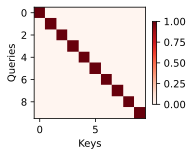

In [3]:
attention_weights = torch.eye(10).reshape((1, 1, 10, 10))
show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries')

## 注意力汇聚：Nadaraya-Watson核回归

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

### 生成数据集

根据下面的非线性函数生成一个人工数据集，其中加入的噪声项为 $\epsilon$：

$$
y_i = 2\sin(x_i) + x_i^{0.8} + \epsilon,
\tag{10.2.1}
$$

其中 $\epsilon$ 服从均值为 0 和标准差为 0.5 的正态分布。在这里生成了 50 个训练样本和 50 个测试样本。为了更好地可视化之后的注意力模式，需要将训练样本进行排序。

In [2]:
n_train = 50 # 训练样本数
x_train, _ = torch.sort(torch.rand(n_train) * 5) # 排序后的训练样本

In [3]:
def f(x):
    return 2 * torch.sin(x) + x**0.8

y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,)) # 训练样本的输出
x_test = torch.arange(0, 5, 0.1) # 测试样本
y_truth= f(x_test)
n_test = len(x_test) # 测试样本数
n_test

50

In [4]:
def plot_kernel_reg(y_hat):
    d2l.plot(x_test, [y_truth, y_hat], 'x', 'y', legend=['Truth', 'Pred'],
                xlim=[0, 5], ylim=[-1, 5])
    d2l.plt.plot(x_train, y_train, 'o', alpha=0.5)

### 平均汇聚

先使用最简单的估计器来解决回归问题。基于平均汇聚来计算所有训练样本输出值的平均值：

$$
f(x) = \frac{1}{n}\sum_{i=1}^{n} y_i,
$$

如下图所示，这个估计器确实不够聪明。真实函数 $f$（“Truth”）和预测函数（“Pred”）相差很大。

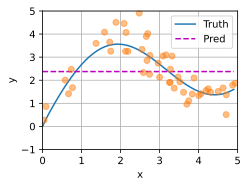

In [5]:
y_hat = torch.repeat_interleave(y_train.mean(), n_test)
plot_kernel_reg(y_hat)

### 非参数注意力汇聚

### 非参数注意力汇聚（Nadaraya–Watson）小结

平均汇聚忽略了输入 $x_i$。Nadaraya–Watson 核回归按输入位置对输出 $y_i$ 加权：

$$
f(x) = \sum_{i=1}^{n} \frac{K(x - x_i)}{\sum_{j=1}^{n} K(x - x_j)} y_i,
$$

其中 $K$ 是核函数。从注意力框架可改写成更一般的**注意力汇聚**：

$$
f(x) = \sum_{i=1}^{n} \alpha(x, x_i) y_i,
$$

- 查询：$x$
- 键值对：$(x_i, y_i)$
- 注意力权重：$\alpha(x, x_i)$（非负且对 $i$ 求和为 1，是有效概率分布）

取高斯核：

$$
K(u) = \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{u^2}{2}\right).
$$

代入后得到：

$$
\begin{aligned}
f(x)
&= \sum_{i=1}^{n} \alpha(x, x_i) y_i \\
&= \sum_{i=1}^{n}
\frac{\exp\left(-\frac{1}{2}(x - x_i)^2\right)}
{\sum_{j=1}^{n} \exp\left(-\frac{1}{2}(x - x_j)^2\right)}
y_i \\
&= \sum_{i=1}^{n}
\mathrm{softmax}\left(-\frac{1}{2}(x - x_i)^2\right) y_i.
\end{aligned}
$$

**直觉**：$x_i$ 越接近查询 $x$，对应 $y_i$ 的权重越大（更受关注）。

**性质**：权重由距离直接算出、无需训练参数，因此是**非参数注意力汇聚**；预测通常比简单平均更平滑、更接近真实曲线。

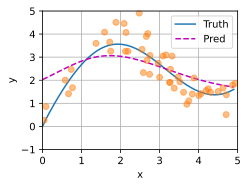

In [6]:
# X_repeat的形状:(n_test, n_train),
# 每一行都包含这相同的测试输入（例如：同样的查询）
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
# X_train包含着键。attention_weights的形状：(n_test, n_train),
# 每一行都包含这要在给定的每个查询的值(y_train)之间分配的注意力权重
attention_weights = nn.functional.softmax(-(X_repeat - x_train)**2 / 2, dim=1)
# y_hat的每个元素都是值的加权平均值，其中的权重是注意力权重
y_hat = torch.matmul(attention_weights, y_train)
plot_kernel_reg(y_hat)

现在来观察注意⼒的权重。这⾥测试数据的输⼊相当于查询，⽽训练数据的输⼊相当于键。因为两个输⼊都
是经过排序的，因此由观察可知“查询-键”对越接近，注意⼒汇聚的注意⼒权重就越⾼。

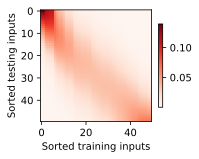

In [7]:
d2l.show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0),
                    xlabel='Sorted training inputs',
                    ylabel='Sorted testing inputs')

### 带参数注意力汇聚

例如，与 (10.2.6) 略有不同，在下面的查询 $x$ 和键 $x_i$ 之间的距离乘以可学习参数 $w$：

$$
\begin{aligned}
f(x)
&= \sum_{i=1}^{n} \alpha(x, x_i) y_i \\
&= \sum_{i=1}^{n}
\frac{\exp\left(-\frac{1}{2}((x - x_i)w)^2\right)}
{\sum_{j=1}^{n} \exp\left(-\frac{1}{2}((x - x_j)w)^2\right)}
y_i \\
&= \sum_{i=1}^{n}
\mathrm{softmax}\left(-\frac{1}{2}((x - x_i)w)^2\right) y_i.
\end{aligned}
$$

本节的余下部分将通过训练这个模型来学习注意力汇聚的参数。

#### 批量矩阵乘法

In [8]:
X = torch.ones((2, 1, 4))
Y = torch.ones((2, 4, 6))
torch.bmm(X, Y).shape

torch.Size([2, 1, 6])

In [9]:
# 在注意⼒机制的背景中，我们可以使⽤⼩批量矩阵乘法来计算⼩批量数据中的加权平均值。
weights = torch.ones((2, 10)) * 0.1
values = torch.arange(20.0).reshape((2, 10))
torch.bmm(weights.unsqueeze(1), values.unsqueeze(-1))

tensor([[[ 4.5000]],

        [[14.5000]]])

#### 定义模型

In [10]:
class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))

    def forward(self, queries, keys, values):
        # queries和attention_weights的形状为(查询个数， "键-值"对个数)
        queries = queries.repeat_interleave(keys.shape[1]).reshape(-1, keys.shape[1])
        self.attention_weights = nn.functional.softmax(-((queries - keys)*self.w)**2 / 2)
        # values的形状为(查询个数，“键-值”对个数)
        return torch.bmm(self.attention_weights.unsqueeze(1),
                            values.unsqueeze(-1)).reshape(-1)

#### 训练

接下来，将训练数据集变换为键和值⽤于训练注意⼒模型。在带参数的注意⼒汇聚模型中，任何⼀个训练样本的输⼊都会和除⾃⼰以外的所有训练样本的“键－值”对进⾏计算，从⽽得到其对应的预测输出。

In [11]:
# X_tile的形状：(n_train, n_train)，每一行都包含着相同的训练输入
X_tile = x_train.repeat((n_train, 1))
# Y_tile的形状：(n_train, n_train)，每一行都包含着相同的训练输出
Y_tile = y_train.repeat((n_train, 1))
# keys的形状：('n_train', 'n_train'-1)
keys = X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))
# values的形状:('n_train'，'n_train'-1)
values = Y_tile[(1- torch.eye(n_train)).type(torch.bool)].reshape((n_train,-1))

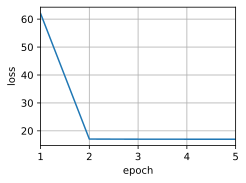

In [12]:
net = NWKernelRegression()
loss = nn.MSELoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.5)
animator = d2l.Animator(xlabel='epoch', ylabel='loss', xlim=[1, 5])

for epoch in range(5):
    trainer.zero_grad()
    l = loss(net(x_train, keys, values), y_train)
    l.sum().backward()
    trainer.step()
    print(f'epoch {epoch + 1}, loss {float(l.sum()):.6f}')
    animator.add(epoch + 1, float(l.sum()))

如下所⽰，训练完带参数的注意⼒汇聚模型后可以发现：在尝试拟合带噪声的训练数据时，预测结果绘制的线不如之前⾮参数模型的平滑。

C:\Users\k\AppData\Local\Temp\ipykernel_36032\502936690.py:9: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  self.attention_weights = nn.functional.softmax(-((queries - keys)*self.w)**2 / 2)


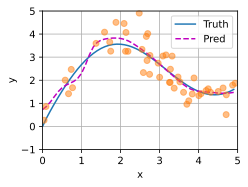

In [13]:
# keys的形状：(n_test, n_train)，每一行包含着相同的训练输入（例如，相同的键）
keys = x_train.repeat((n_test, 1))
# value的形状：(n_test, n_train)
values = y_train.repeat((n_test, 1))
y_hat = net(x_test, keys, values).unsqueeze(1).detach()
plot_kernel_reg(y_hat)

为什么新的模型更不平滑了呢？下⾯看⼀下输出结果的绘制图：与⾮参数的注意⼒汇聚模型相⽐，带参数的模型加⼊可学习的参数后，曲线在注意⼒权重较⼤的区域变得更不平滑。

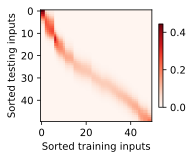

In [14]:
d2l.show_heatmaps(net.attention_weights.unsqueeze(0).unsqueeze(0),
xlabel='Sorted training inputs',
ylabel='Sorted testing inputs')

## 注意力评分函数

从宏观来看，上述算法可以用来实现图10.1.3中的注意力机制框架。图10.3.1说明了如何将注意力汇聚的输出计算成为值的加权和，其中 $a$ 表示注意力评分函数。由于注意力权重是概率分布，因此加权和本质上是加权平均值。

<div align="center">
    <img src="../img/计算注意力汇聚的输出值为加权和.png">
<div>

假设有一个查询 $\mathbf{q} \in \mathbb{R}^q$ 和 $m$ 个“键－值”对 $(\mathbf{k}_1, \mathbf{v}_1), \ldots, (\mathbf{k}_m, \mathbf{v}_m)$，其中 $\mathbf{k}_i \in \mathbb{R}^k$，$\mathbf{v}_i \in \mathbb{R}^v$。注意力汇聚函数 $f$ 表示成值的加权和：

$$
f(\mathbf{q}, (\mathbf{k}_1, \mathbf{v}_1), \ldots, (\mathbf{k}_m, \mathbf{v}_m))
= \sum_{i=1}^{m} \alpha(\mathbf{q}, \mathbf{k}_i) \mathbf{v}_i \in \mathbb{R}^v.
$$

其中注意力权重（标量）由评分函数 $a$ 打分后再经 softmax 得到：

$$
\alpha(\mathbf{q}, \mathbf{k}_i)
= \mathrm{softmax}(a(\mathbf{q}, \mathbf{k}_i))
= \frac{\exp(a(\mathbf{q}, \mathbf{k}_i))}{\sum_{j=1}^{m} \exp(a(\mathbf{q}, \mathbf{k}_j))} \in \mathbb{R}.
$$

**小结**：选不同的 $a$ 会得到不同的注意力汇聚；后面常用的是加性注意力和缩放点积注意力。

In [1]:
import math
import torch
from torch import nn
from d2l import torch as d2l

### 掩蔽softmax操作

在某些情况下，并⾮所有的值都应该被纳⼊到注意⼒汇聚中。例如，为了在9.5节中⾼效处理⼩批量数据集，某些⽂本序列被填充了没有意义的特殊词元。为了仅将有意义的词元作为值来获取注意⼒汇聚，可以指定⼀个有效序列⻓度（即词元的个数），以便在计算softmax时过滤掉超出指定范围的位置。下⾯的masked_softmax函数实现了这样的掩蔽softmax操作（maskedsoftmaxoperation），其中任何超出有效⻓度的位置都被掩蔽并置为0。

In [12]:
#@save
def masked_softmax(X, valid_lens):
    """通过在最后一个轴上掩蔽元素来执行softmax操作"""
    # X:3D张量，未遮蔽的注意力分数，形状：(批量大小，查询个数，键的个数)
    # valid_lens:1D或2D张量
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        # 最后一轴上被遮蔽的元素使用一个非常大的负值替换，从而器softmax输出为0
        X = d2l.sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)


In [13]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([2, 3]))

tensor([[[0.5527, 0.4473, 0.0000, 0.0000],
         [0.6035, 0.3965, 0.0000, 0.0000]],

        [[0.1962, 0.3715, 0.4323, 0.0000],
         [0.3774, 0.3664, 0.2561, 0.0000]]])

同样，也可以使用二维张量，为矩阵样本中的每一行指定有效长度

In [14]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([[1, 3], [2, 4]]))

tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.4077, 0.2993, 0.2929, 0.0000]],

        [[0.5942, 0.4058, 0.0000, 0.0000],
         [0.3231, 0.2090, 0.1884, 0.2794]]])

### 加性注意力

一般来说，当查询和键是不同长度的矢量时，可以使用加性注意力作为评分函数。给定查询 $\mathbf{q} \in \mathbb{R}^q$ 和键 $\mathbf{k} \in \mathbb{R}^k$，加性注意力（additive attention）的评分函数为

$$
a(\mathbf{q}, \mathbf{k}) = \mathbf{w}_v^\top \tanh(\mathbf{W}_q \mathbf{q} + \mathbf{W}_k \mathbf{k}) \in \mathbb{R}.
$$

其中可学习的参数是 $\mathbf{W}_q \in \mathbb{R}^{h \times q}$、$\mathbf{W}_k \in \mathbb{R}^{h \times k}$ 和 $\mathbf{w}_v \in \mathbb{R}^{h}$。如 (10.3.3) 所示，将查询和键连结起来后输入到一个多层感知机（MLP）中，感知机包含一个隐藏层，其隐藏单元数是一个超参数 $h$。通过使用 $\tanh$ 作为激活函数，并且禁用偏置项。

#### 如何理解加性注意力

评分函数（一个询问和一个键的分数）：

$$
a(\mathbf{q}, \mathbf{k}) = \mathbf{w}_v^\top \tanh(\mathbf{W}_q \mathbf{q} + \mathbf{W}_k \mathbf{k}) \in \mathbb{R}
\tag{10.3.3}
$$

#### 1. 投影（统一维度）—— $\mathbf{W}_q\mathbf{q}$、$\mathbf{W}_k\mathbf{k}$

公式含义：查询 $\mathbf{q}$ 和键 $\mathbf{k}$ 本来可能是不同维度的（比如 $q$ 维和 $k$ 维），就像一个是法语，一个是德语。$\mathbf{W}_q$ 和 $\mathbf{W}_k$ 就是“翻译官”。它们将不同维度的输入，分别投影到同一个隐藏空间（维度统一为 `num_hiddens`）。

记忆点：既然要“加”在一起，前提条件必须是它们的维度一样大。所以必须先乘上权重矩阵进行映射。

#### 2. 融合（非线性）—— $\tanh(\mathbf{W}_q\mathbf{q} + \mathbf{W}_k\mathbf{k})$

- 相加：这就是“加性”名字的来源。
- $\tanh$：引入非线性，表达查询–键更复杂的匹配关系。
- 与“先拼接再乘一块大矩阵”等价；代码里通常是先分别投影再相加。

#### 3. 打分（压成标量）—— $\mathbf{w}_v^\top(\cdots)$

- 前面得到的是 $h$ 维向量，需要变成一个相关性分数。
- $\mathbf{w}_v$ 把该向量加权收成标量 $a(\mathbf{q},\mathbf{k})$。

之后照常：

$$
\alpha(\mathbf{q}, \mathbf{k}_i) = \mathrm{softmax}\bigl(a(\mathbf{q}, \mathbf{k}_i)\bigr)
\quad\Rightarrow\quad
\sum_i \alpha_i \mathbf{v}_i
$$

#### 对应代码

| 代码 | 公式 |
|------|------|
| `queries = self.W_q(queries)` | $\mathbf{W}_q\mathbf{q}$ |
| `keys = self.W_k(keys)` | $\mathbf{W}_k\mathbf{k}$ |
| `features = queries.unsqueeze(2) + keys.unsqueeze(1)` | $\mathbf{W}_q\mathbf{q} + \mathbf{W}_k\mathbf{k}$（广播到所有查询–键对） |
| `features = torch.tanh(features)` | $\tanh(\cdots)$ |
| `scores = self.w_v(features).squeeze(-1)` | $\mathbf{w}_v^\top(\cdots)$ |

#### 和点积注意力对比

- **加性**：查询/键维度可以不同；有 $\tanh$ 非线性。
- **点积**：要求同维，计算更快；Transformer 里更常用**缩放点积**。

#### 口诀

> 先投影对齐 → 再相加融合 → $\tanh$ 非线性 → $\mathbf{w}_v$ 压成标量分数。

In [21]:
#@save
class AdditiveAttention(nn.Module):
    """加性注意力"""
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        # querices形状：(batch_size, 查询个数, query_size)
        # keys形状：(batch_size, 键-值对个数, key_size)
        # values形状：(batch_size, 键-值对个数, values_size)
        queries, keys = self.W_q(queries), self.W_k(keys)
        # 在维度扩展后，
        # queries的形状：(batch_size, 查询的个数, 1, num_hiddens)
        # key的形状：(batch_size, 1, “键-值”对的个数, num_hiddens)
        # 使用广播方式进行求和
        # 这里广播相当于把queries和key都变为(batch_size, 查询个数*“键-值”对个数, num_hiddens)，
        # 虽然实际形状不是这么变化，但是效果是完全一样的，可以作为理解
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        # self.w_v仅有一个输出，因此从形状中一处最后那个维度
        # scores的形状：(batch_size, 查询的个数, “键-值”对的个数)
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax(scores, valid_lens)
        # values的形状：(batch_size, “键-值”对的个数, 值的维度)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [22]:
queries, keys = torch.normal(0, 1, (2, 1, 20)), torch.ones((2, 10, 2))
# values的小批量，两个值矩阵是相同的
values = torch.arange(40, dtype=torch.float32).reshape(1, 10, 4).repeat(2, 1, 1)
valid_lens = torch.tensor([2, 6])

attention = AdditiveAttention(key_size=2, query_size=20, num_hiddens=8,
                                dropout=0.1)
attention.eval()
attention(queries, keys, values, valid_lens)

tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]], grad_fn=<BmmBackward0>)

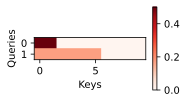

In [23]:
d2l.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                    xlabel='Keys', ylabel='Queries')